In [39]:
import random
from time import time

In [40]:
def parse_instance(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Remove empty lines
    lines = [line.strip() for line in lines if line.strip()]

    # Find line with "jobs machines"
    for i, line in enumerate(lines):
        if line[0].isdigit():
            jobs, machines = map(int, line.split())
            start_index = i + 1
            break

    jobs_data = []

    for line in lines[start_index:start_index + jobs]:
        numbers = list(map(int, line.split()))
        operations = []
        for i in range(0, len(numbers), 2):
            machine = numbers[i]
            duration = numbers[i + 1]
            operations.append((machine, duration))
        jobs_data.append(operations)

    return jobs, machines, jobs_data

In [41]:
class Individual:
    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = None


def generate_chromosome(num_jobs, num_machines):
    chromosome = []
    for job in range(num_jobs):
        chromosome += [job] * num_machines
    random.shuffle(chromosome)
    return chromosome

In [42]:
def compute_makespan(chromosome, jobs_data):
    num_jobs = len(jobs_data)
    num_machines = len(jobs_data[0])

    job_next_op = [0] * num_jobs
    job_end_time = [0] * num_jobs
    machine_end_time = [0] * num_machines

    for job in chromosome:
        op_index = job_next_op[job]
        machine, duration = jobs_data[job][op_index]

        start_time = max(job_end_time[job], machine_end_time[machine])
        end_time = start_time + duration

        job_end_time[job] = end_time
        machine_end_time[machine] = end_time
        job_next_op[job] += 1

    return max(job_end_time)

def population_fitness_sort(population, jobs_data):
    for ind in population:
        ind.fitness = compute_makespan(ind.chromosome, jobs_data)

    population.sort(key=lambda x: x.fitness)
    return population


In [43]:

def tournament_selection(population, k=3):
    contenders = random.sample(population, k)
    contenders.sort(key=lambda x: x.fitness)
    return contenders[0]

def crossover(parent1, parent2, num_jobs, num_machines):
    size = len(parent1.chromosome)

    a, b = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[a:b] = parent1.chromosome[a:b]

    required_count = {job: num_machines for job in range(num_jobs)}

    for gene in child[a:b]:
        required_count[gene] -= 1

    fill_index = 0
    for gene in parent2.chromosome:
        if required_count[gene] > 0:
            while child[fill_index] is not None:
                fill_index += 1
            child[fill_index] = gene
            required_count[gene] -= 1

    return Individual(child)

def mutate(individual, mutation_rate):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual.chromosome)), 2)
        individual.chromosome[i], individual.chromosome[j] = \
            individual.chromosome[j], individual.chromosome[i]
    return individual


In [44]:
def genetic_algorithm(file_path,
                      population_size=100,
                      generations=200,
                      mutation_rate=0.1,
                      elites=2,
                      runs=1):

    def _single_run():
        num_jobs, num_machines, jobs_data = parse_instance(file_path)

        population = [
            Individual(generate_chromosome(num_jobs, num_machines))
            for _ in range(population_size)
        ]

        best_overall = None

        for gen in range(generations):
            population = population_fitness_sort(population, jobs_data)

            if best_overall is None or population[0].fitness < best_overall.fitness:
                best_overall = population[0]

            print(f"Generation {gen} | Best makespan: {population[0].fitness}")

            new_population = population[:elites]

            while len(new_population) < population_size:
                p1 = tournament_selection(population)
                p2 = tournament_selection(population)

                child = crossover(p1, p2, num_jobs, num_machines)
                child = mutate(child, mutation_rate)

                new_population.append(child)

            population = new_population

        print("\nBest solution found:")
        print("Makespan:", best_overall.fitness)
        return best_overall

    results = []
    best_global = None

    for r in range(runs):
        print(f"\n=== Run {r+1}/{runs} ===")
        best = _single_run()
        results.append(best.fitness)

        if best_global is None or best.fitness < best_global.fitness:
            best_global = best

    avg = sum(results) / len(results) if results else float("inf")
    print(f"\nAverage makespan over {runs} runs: {avg}")
    return best_global, avg

In [45]:
if __name__ == "__main__":
    best = genetic_algorithm("abz5.txt",
                             population_size=200,
                             generations=1000,
                             mutation_rate=0.2,
                             elites=5,
                             runs=1)



=== Run 1/1 ===
Generation 0 | Best makespan: 1719
Generation 1 | Best makespan: 1654
Generation 2 | Best makespan: 1654
Generation 3 | Best makespan: 1654
Generation 4 | Best makespan: 1615
Generation 5 | Best makespan: 1604
Generation 6 | Best makespan: 1551
Generation 7 | Best makespan: 1551
Generation 8 | Best makespan: 1551
Generation 9 | Best makespan: 1551
Generation 10 | Best makespan: 1513
Generation 11 | Best makespan: 1513
Generation 12 | Best makespan: 1513
Generation 13 | Best makespan: 1513
Generation 14 | Best makespan: 1493
Generation 15 | Best makespan: 1474
Generation 16 | Best makespan: 1474
Generation 17 | Best makespan: 1474
Generation 18 | Best makespan: 1430
Generation 19 | Best makespan: 1430
Generation 20 | Best makespan: 1430
Generation 21 | Best makespan: 1428
Generation 22 | Best makespan: 1428
Generation 23 | Best makespan: 1428
Generation 24 | Best makespan: 1425
Generation 25 | Best makespan: 1421
Generation 26 | Best makespan: 1414
Generation 27 | Best 


=== Instance abz5 ===
[abz5] Running x1...
[abz5.txt] Run 1 1/25 started...
[abz5.txt] Run 1/25 done.
[abz5.txt] Run 2 2/25 started...
[abz5.txt] Run 2/25 done.
[abz5.txt] Run 3 3/25 started...
[abz5.txt] Run 3/25 done.
[abz5.txt] Run 4 4/25 started...
[abz5.txt] Run 4/25 done.
[abz5.txt] Run 5 5/25 started...
[abz5.txt] Run 5/25 done.
[abz5.txt] Run 6 6/25 started...
[abz5.txt] Run 6/25 done.
[abz5.txt] Run 7 7/25 started...
[abz5.txt] Run 7/25 done.
[abz5.txt] Run 8 8/25 started...
[abz5.txt] Run 8/25 done.
[abz5.txt] Run 9 9/25 started...
[abz5.txt] Run 9/25 done.
[abz5.txt] Run 10 10/25 started...
[abz5.txt] Run 10/25 done.
[abz5.txt] Run 11 11/25 started...
[abz5.txt] Run 11/25 done.
[abz5.txt] Run 12 12/25 started...
[abz5.txt] Run 12/25 done.
[abz5.txt] Run 13 13/25 started...
[abz5.txt] Run 13/25 done.
[abz5.txt] Run 14 14/25 started...
[abz5.txt] Run 14/25 done.
[abz5.txt] Run 15 15/25 started...
[abz5.txt] Run 15/25 done.
[abz5.txt] Run 16 16/25 started...
[abz5.txt] Run 16/

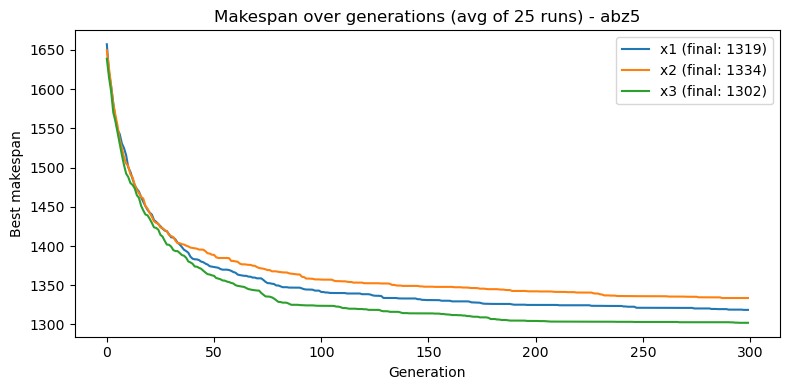


=== Instance abz6 ===
[abz6] Running x1...
[abz6.txt] Run 1 1/25 started...
[abz6.txt] Run 1/25 done.
[abz6.txt] Run 2 2/25 started...
[abz6.txt] Run 2/25 done.
[abz6.txt] Run 3 3/25 started...
[abz6.txt] Run 3/25 done.
[abz6.txt] Run 4 4/25 started...
[abz6.txt] Run 4/25 done.
[abz6.txt] Run 5 5/25 started...
[abz6.txt] Run 5/25 done.
[abz6.txt] Run 6 6/25 started...
[abz6.txt] Run 6/25 done.
[abz6.txt] Run 7 7/25 started...
[abz6.txt] Run 7/25 done.
[abz6.txt] Run 8 8/25 started...
[abz6.txt] Run 8/25 done.
[abz6.txt] Run 9 9/25 started...
[abz6.txt] Run 9/25 done.
[abz6.txt] Run 10 10/25 started...
[abz6.txt] Run 10/25 done.
[abz6.txt] Run 11 11/25 started...
[abz6.txt] Run 11/25 done.
[abz6.txt] Run 12 12/25 started...
[abz6.txt] Run 12/25 done.
[abz6.txt] Run 13 13/25 started...
[abz6.txt] Run 13/25 done.
[abz6.txt] Run 14 14/25 started...
[abz6.txt] Run 14/25 done.
[abz6.txt] Run 15 15/25 started...
[abz6.txt] Run 15/25 done.
[abz6.txt] Run 16 16/25 started...
[abz6.txt] Run 16/

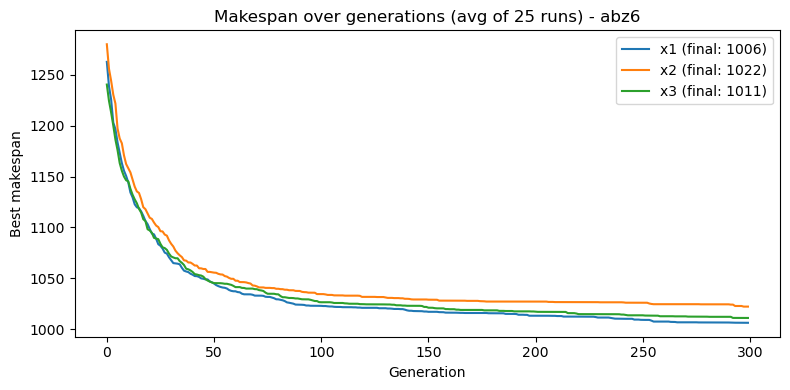


=== Instance abz7 ===
[abz7] Running x1...
[abz7.txt] Run 1 1/25 started...
[abz7.txt] Run 1/25 done.
[abz7.txt] Run 2 2/25 started...
[abz7.txt] Run 2/25 done.
[abz7.txt] Run 3 3/25 started...
[abz7.txt] Run 3/25 done.
[abz7.txt] Run 4 4/25 started...
[abz7.txt] Run 4/25 done.
[abz7.txt] Run 5 5/25 started...
[abz7.txt] Run 5/25 done.
[abz7.txt] Run 6 6/25 started...
[abz7.txt] Run 6/25 done.
[abz7.txt] Run 7 7/25 started...
[abz7.txt] Run 7/25 done.
[abz7.txt] Run 8 8/25 started...
[abz7.txt] Run 8/25 done.
[abz7.txt] Run 9 9/25 started...
[abz7.txt] Run 9/25 done.
[abz7.txt] Run 10 10/25 started...
[abz7.txt] Run 10/25 done.
[abz7.txt] Run 11 11/25 started...
[abz7.txt] Run 11/25 done.
[abz7.txt] Run 12 12/25 started...
[abz7.txt] Run 12/25 done.
[abz7.txt] Run 13 13/25 started...
[abz7.txt] Run 13/25 done.
[abz7.txt] Run 14 14/25 started...
[abz7.txt] Run 14/25 done.
[abz7.txt] Run 15 15/25 started...
[abz7.txt] Run 15/25 done.
[abz7.txt] Run 16 16/25 started...
[abz7.txt] Run 16/

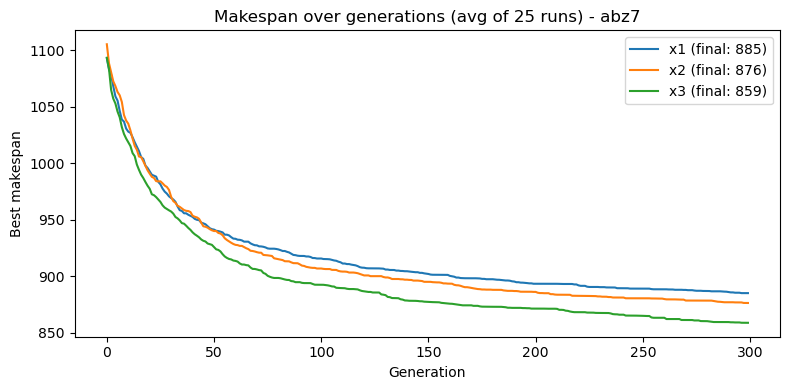

In [46]:
# ...existing code...
import matplotlib.pyplot as plt

def run_ga_collect_curve(file_path, population_size, generations, mutation_rate, elites, runs=25):
    num_jobs, num_machines, jobs_data = parse_instance(file_path)
    all_curves = []
    for run_idx in range(1, runs + 1):
        print(f"[{file_path}] Run {run_idx} {run_idx}/{runs} started...")
        population = [
            Individual(generate_chromosome(num_jobs, num_machines))
            for _ in range(population_size)
        ]
        best_curve = []

        for _gen in range(generations):
            population = population_fitness_sort(population, jobs_data)
            best_curve.append(population[0].fitness)

            new_population = population[:elites]
            while len(new_population) < population_size:
                p1 = tournament_selection(population)
                p2 = tournament_selection(population)
                child = crossover(p1, p2, num_jobs, num_machines)
                child = mutate(child, mutation_rate)
                new_population.append(child)

            population = new_population

        all_curves.append(best_curve)
        print(f"[{file_path}] Run {run_idx}/{runs} done.")

    avg_curve = [sum(gen_vals) / len(gen_vals) for gen_vals in zip(*all_curves)]
    return avg_curve

# --- Parameter sets (same for all instances) ---
x1 = dict(population_size=200, generations=300, mutation_rate=0.20, elites=5)
x2 = dict(population_size=150, generations=300, mutation_rate=0.10, elites=3)
x3 = dict(population_size=250, generations=300, mutation_rate=0.30, elites=8)

instances = [
    ("abz5.txt", "abz5"),
    ("abz6.txt", "abz6"),
    ("abz7.txt", "abz7"),
]

for path, label in instances:
    print(f"\n=== Instance {label} ===")
    
    print(f"[{label}] Running x1...")
    c1 = run_ga_collect_curve(path, runs=25, **x1)
    print(f"[{label}] x1 done. Final avg makespan: {c1[-1]:.2f}")
    
    print(f"[{label}] Running x2...")
    c2 = run_ga_collect_curve(path, runs=25, **x2)
    print(f"[{label}] x2 done. Final avg makespan: {c2[-1]:.2f}")
    
    print(f"[{label}] Running x3...")
    c3 = run_ga_collect_curve(path, runs=25, **x3)
    print(f"[{label}] x3 done. Final avg makespan: {c3[-1]:.2f}")

    plt.figure(figsize=(8, 4))
    plt.plot(c1, label=f"x1 (final: {c1[-1]:.0f})")
    plt.plot(c2, label=f"x2 (final: {c2[-1]:.0f})")
    plt.plot(c3, label=f"x3 (final: {c3[-1]:.0f})")
    plt.title(f"Makespan over generations (avg of 25 runs) - {label}")
    plt.xlabel("Generation")
    plt.ylabel("Best makespan")
    plt.legend()
    plt.tight_layout()
    plt.show()
# ...existing code...